In [1]:
# http://www.acgeospatial.co.uk/sentinel-5p-and-python/

import netCDF4

from netCDF4 import Dataset

import numpy as np

import glob

import pandas as pd

import matplotlib.pyplot as plt

from mpl_toolkits.basemap import Basemap

import os

In [2]:
path = 'C:\\Users\\akiec\\Downloads\\October\\'
for filename in glob.glob(os.path.join(path,'*.nc')):
    fh=netCDF4.Dataset(filename,'r')
    print(fh)

##filelist= glob.glob(r'C:\\Users\\akiec\\Downloads\\Weekend*.nc')
##fh = Dataset(filelist,mode = 'r')
#my_nc_file= (r"C:\Users\akiec\Downloads\Weekend\S5P_OFFL_L2__NO2____20181202T193613_20181202T211743_05894_01_010202_20181208T211843.nc")#my_nc_file=(r"C:\Users\akiec\Downloads\Weekend\S5P_OFFL_L2__NO2____20181201T195518_20181201T213647_05880_01_010202_20181207T214952.nc")
#fh = Dataset(my_nc_file,mode = 'r')#create variable that reads in NO2 observed data for x days
#variable will be a list of files 
#create a new variable with y dimension average 

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.7
    institution: KNMI
    source: Sentinel 5 precursor, TROPOMI, space-borne remote sensing, L2
    history: 2018-11-01 18:56:41 f_s5pops tropnll2dp /mnt/data1/storage_offl_l2/cache_offl_l2/WORKING-564737083/JobOrder.564737059.xml
    summary: TROPOMI/S5P Aerosol Index 1-Orbit L2 Swath 7x3.5km
    tracking_id: 9a56bd48-541b-4c2d-871d-abc21b9498f7
    id: S5P_OFFL_L2__AER_AI_20181026T193249_20181026T211419_05369_01_010200_20181101T185257
    time_reference: 2018-10-26T00:00:00Z
    time_reference_days_since_1950: 25135
    time_reference_julian_day: 2458417.5
    time_reference_seconds_since_1970: 1540512000
    time_coverage_start: 2018-10-26T19:54:24Z
    time_coverage_end: 2018-10-26T20:52:47Z
    time_coverage_duration: PT3503.000S
    time_coverage_resolution: PT1.080S
    orbit: 5369
    references: http://www.tropomi.eu/data-products/aerosol-index
    processor_version: 1

In [3]:
lons = fh.groups['PRODUCT'].variables['longitude'][:][0,:,:]

lats = fh.groups['PRODUCT'].variables['latitude'][:][0,:,:]

no2 = fh.groups['PRODUCT'].variables['nitrogendioxide_tropospheric_column_precision'][0,:,:]

print(np.mean(no2))

7.978506436561867e-06


In [4]:
no2_units = fh.groups['PRODUCT'].variables['nitrogendioxide_tropospheric_column_precision'].units

In [5]:
#%matplotlib inline

from matplotlib.colors import LogNorm

In [6]:
lon_0 = lons.mean()
lat_0 = lats.mean()

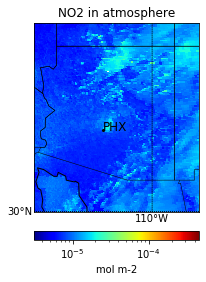

In [7]:
m = Basemap(projection='cyl', resolution='l',

            llcrnrlon=-115,llcrnrlat=30,urcrnrlon=-108,urcrnrlat=38) #this is where you can zoom as desired

xi, yi = m(lons, lats)

# Plot Data

cs = m.pcolor(xi,yi,np.squeeze(no2),norm=LogNorm(), cmap='jet')
# Add Grid Lines

m.drawparallels(np.arange(-80., 81., 10.), labels=[1,0,0,0], fontsize=10)

m.drawmeridians(np.arange(-180., 181., 10.), labels=[0,0,0,1], fontsize=10)

# Add Coastlines, States, and Country Boundaries

m.drawcoastlines()

m.drawstates()

m.drawcountries()
#map (lat, long) to (x,y)
x,y = m(-112.0740, 33.4484)
plt.plot(x,y, 'ok', markersize=2)
plt.text(x,y, 'PHX', fontsize=12)

cbar = m.colorbar(cs, location='bottom', pad="10%")

cbar.set_label(no2_units)

# Add Title

plt.title('NO2 in atmosphere')
plt.show()